# Yield Simulator for D2W Hybrid Bonding
#### Author: Zhichao Chen
#### Date: Oct 23, 2025
#### Description: YAP+ESD-Stress (pad-layout-aware yield analysis)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator
from spatial_correlation_coefficients_precalculate import Spatial_Correlation_Coefficients_Precalculate

In [1]:
# Load configuration
cfg = load_modeling_config(path='configs/HBM_footprint_B_config.yaml', 
                     mode='d2w_simulation',
                     debug=False)

# Generate pad bitmap collection
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                     blox_bmap_path='input/' + cfg.INTERFACE + '.bmap',
                                                     criticality_path='input/' + cfg.INTERFACE + '_criticality.txt',
                                                     pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)

start_time = time.time()

# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='d2w_simulation')
cfg.NUM_DIES = 5  # For correlation coefficient precalculation, only 1 die is needed
cfg.SYSTEM_ROTATION_MEAN_rad = 7e-4
cfg.TOP_DISH_MEAN_nm = -0.0 
cfg.TOP_DISH_STD_nm = 0.3 
cfg.BOT_DISH_MEAN_nm = -0.0
cfg.BOT_DISH_STD_nm = 0.3 
cfg.D0 = 1e-7
Spatial_Correlation_Coefficients_Precalculate(
    cfg=cfg,
    pad_bitmap_collection=pad_bitmap_collection,                                               
)

NameError: name 'load_modeling_config' is not defined

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Simulation progress: 1000/1000 epochs completed.
Simulation Completed.

Assembly Yield: 82.06%
Total time taken: 76.32 seconds


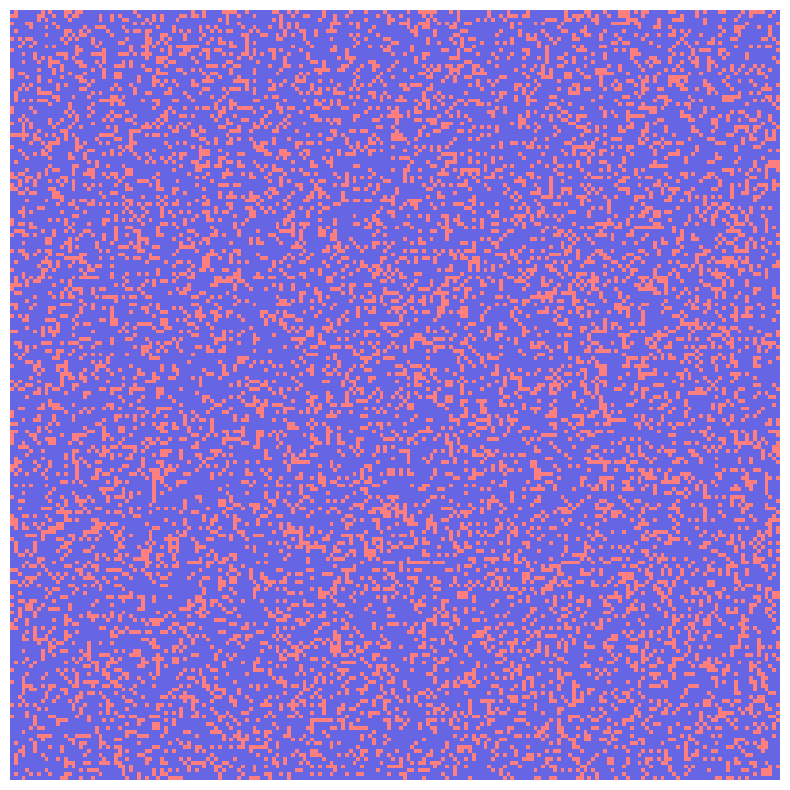

In [6]:
# Load configuration
cfg = load_modeling_config(path='configs/random_10x10_50.yaml',
                     mode='d2w_simulation',
                     debug=False)

# Generate pad bitmap collection
# pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
#                                                      blox_bmap_path='pad_bitmap/HBM_footprint_A.bmap', 
#                                                      pad_arrange_pattern='checkerboard')  
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                    #  blox_bmap_path=cfg.INPUT_DIR + cfg.INTERFACE + '.bmap',
    blox_bmap_path=cfg.INPUT_DIR + 'random_10x10_50.bmap',
    criticality_path=cfg.INPUT_DIR + 'random_10x10_50_criticality.txt',
    pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)

start_time = time.time()

# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='d2w_simulation')

assembly_yield, single_config_yield_list = Assembly_Yield_Simulator(
    cfg=cfg,
    pad_bitmap_collection=pad_bitmap_collection,                                               
)
print("\nAssembly Yield: {:.2f}%".format(assembly_yield * 100))
    
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))

Running assembly yield simulator over 100 dies...
Verbose mode enabled: Tracking failure reasons for each die.


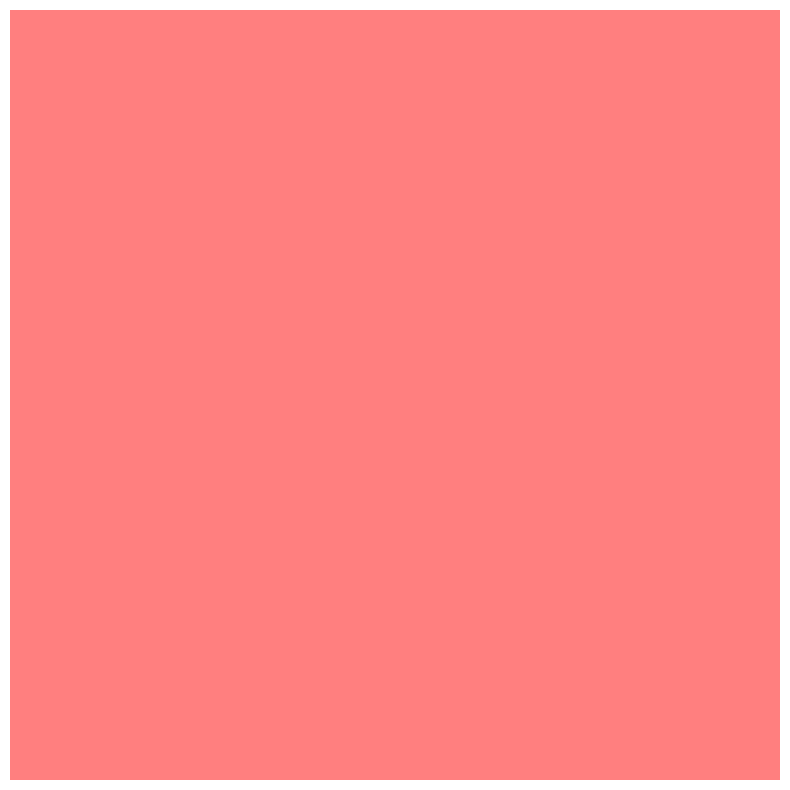

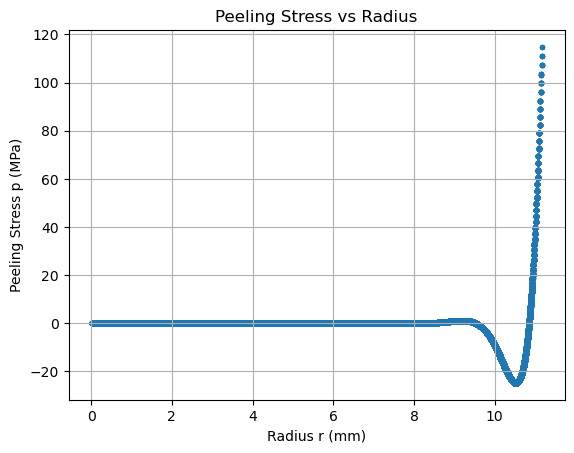

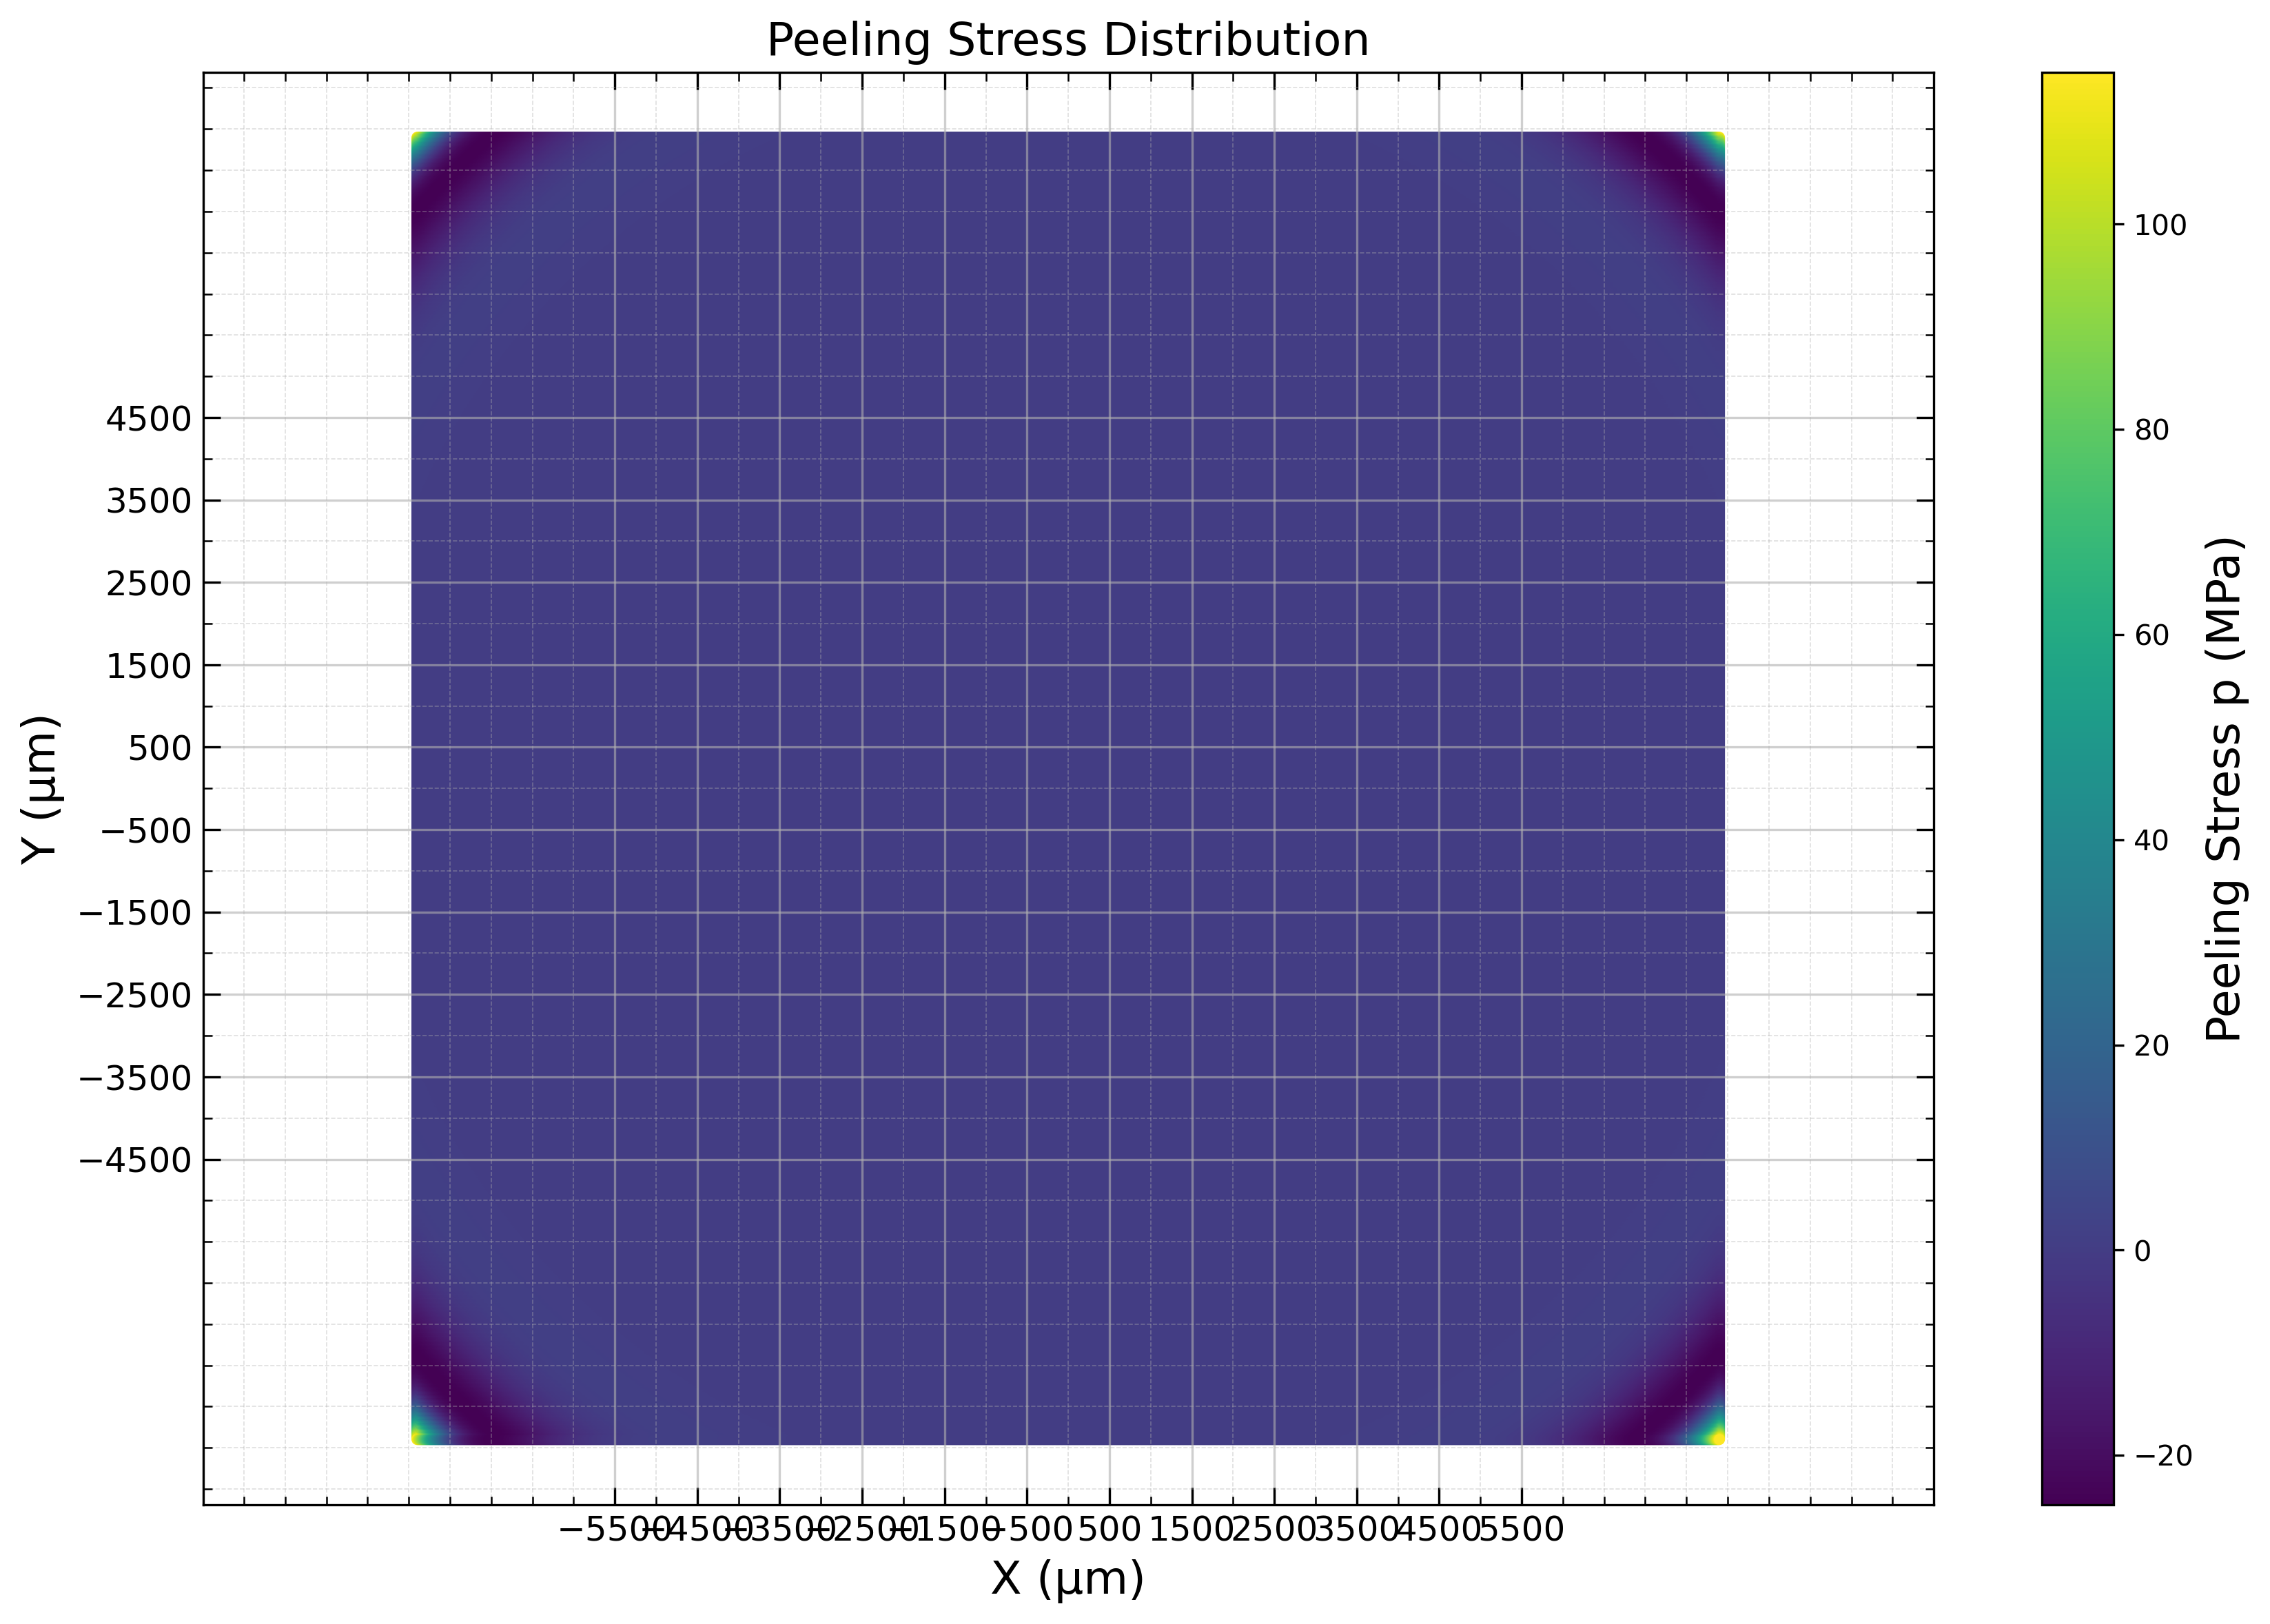

Simulation progress: 10/10 epochs completed.
Simulation Completed.
2 die failures due to overlay misalignment.
17 die failures due to particle defects.
96 die failures due to mechanical issues.
0 die failures due to ESD issues.
97 die failures in total.
Failure heat maps saved to output/Compute_Large_Top_From_Compute_Large_Bottom/assembly_fail_map_dict.npz.
Failure vectors for all die samples saved to output/Compute_Large_Top_From_Compute_Large_Bottom/assembly_fail_vec_dict.npz.
Failure map for overlay saved to output/Compute_Large_Top_From_Compute_Large_Bottomfailure_map_overlay.png
Failure map for particle saved to output/Compute_Large_Top_From_Compute_Large_Bottomfailure_map_particle.png
Failure map for mechanical saved to output/Compute_Large_Top_From_Compute_Large_Bottomfailure_map_mechanical.png
Failure map for ESD saved to output/Compute_Large_Top_From_Compute_Large_Bottomfailure_map_ESD.png
Failure map for overall saved to output/Compute_Large_Top_From_Compute_Large_Bottomfailu

In [ ]:
base_config_path='configs/design_8.yaml'
# Extract the design input files directory if provided
input_ds_dir = 'input/design_8'
# Determine .3dbv path
_3dbv_path = input_ds_dir + "/generated_chiplet_definitions.3dbv"
# Determine .bmap path
_bmap_path = 'input/design_8/Compute_Large_Top_From_Compute_Large_Bottom.bmap'

# Load config and update with design and ADK parameters (from .3dbv and .bmap)
cfg = load_base_config(base_config_path=base_config_path,
                        input_ds_dir=input_ds_dir,
                        _3dbv_path=_3dbv_path,
                        _bmap_path=_bmap_path,
                        mode='d2w_simulation', 
                        debug=False)

# Plotting flag
cfg.plot_flag = False

# Create output directory if it doesn't exist
if not os.path.exists(cfg.OUTPUT_DIR + cfg.INTERFACE):
    os.makedirs(cfg.OUTPUT_DIR + cfg.INTERFACE)

# Determine criticality path
criticality_path = 'input/design_8/Compute_Large_Top_From_Compute_Large_Bottom_criticality.txt'

# Verbose flag
cfg.verbose = True

# Step 1: convert .bmap -> pad bitmap collection
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                    _bmap_path=_bmap_path,
                                                    criticality_path=criticality_path,
                                                    pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)

# Step 2: run assembly yield simulator
print("Running assembly yield simulator over {} dies...".format(cfg.NUM_DIES))
start_time = time.time()
assembly_yield, _ = Assembly_Yield_Simulator(
    cfg=cfg,
    mode='d2w_simulation',
    pad_bitmap_collection=pad_bitmap_collection,                                               
)

print(f"Assembly yield over {cfg.NUM_DIES} simulations: {assembly_yield*100:.2f}%")
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))